<a href="https://colab.research.google.com/github/chigur-DA/E-Commerce-Data-Analytics-Statistical-Hypothesis-Testing/blob/main/E_Commerce_Data_Analytics_%26_Statistical_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Авторизація
auth.authenticate_user()
project_id = "data-analytics-mate"
client = bigquery.Client(project=project_id)

# 2. SQL-запит
sql_query = """
SELECT
    s.date AS order_date,
    s.ga_session_id AS session_id,
    sp.continent AS continent,
    sp.country AS country,
    sp.device AS device,
    sp.browser AS browser,
    sp.mobile_model_name AS device_model,
    sp.operating_system AS os,
    sp.language AS browser_lang,
    sp.medium AS traffic_source,
    sp.channel AS traffic_channel,
    a.id AS user_id,
    a.is_verified AS is_email_confirmed,
    a.is_unsubscribed AS is_subscribed,
    p.category AS category,
    p.name AS product_name,
    p.price AS price
FROM `data-analytics-mate.DA.session` s
LEFT JOIN `data-analytics-mate.DA.session_params` sp
    ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.order` o
    ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` p
    ON o.item_id = p.item_id
LEFT JOIN `data-analytics-mate.DA.account_session` acts
    ON s.ga_session_id = acts.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` a
    ON acts.account_id = a.id
"""


df = client.query(sql_query).to_dataframe(create_bqstorage_client=False)
df.head()


,order_date,session_id,continent,country,device,browser,device_model,os,browser_lang,traffic_source,traffic_channel,user_id,is_email_confirmed,is_subscribed,category,product_name,price
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_date          349545 non-null  dbdate 
 1   session_id          349545 non-null  Int64  
 2   continent           349545 non-null  object 
 3   country             349545 non-null  object 
 4   device              349545 non-null  object 
 5   browser             349545 non-null  object 
 6   device_model        349545 non-null  object 
 7   os                  349545 non-null  object 
 8   browser_lang        235279 non-null  object 
 9   traffic_source      349545 non-null  object 
 10  traffic_channel     349545 non-null  object 
 11  user_id             27945 non-null   Int64  
 12  is_email_confirmed  27945 non-null   Int64  
 13  is_subscribed       27945 non-null   Int64  
 14  category            33538 non-null   object 
 15  product_name        33538 non-null

In [ ]:
df.describe(include='all')

,order_date,session_id,continent,country,device,browser,device_model,os,browser_lang,traffic_source,traffic_channel,user_id,is_email_confirmed,is_subscribed,category,product_name,price
count,349545,349545.0,349545,349545,349545,349545,349545,349545,235279,349545,349545,27945.0,27945.0,27945.0,33538,33538,33538.000000
unique,92,<NA>,6,108,3,6,10,6,9,6,5,<NA>,<NA>,<NA>,14,550,NaN
top,2020-12-08,<NA>,Americas,United States,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,BESTÅ,NaN
freq,7212,<NA>,193179,153470,204429,238460,97254,203909,159893,119024,124425,<NA>,<NA>,<NA>,7630,1257,NaN
mean,NaN,4992250296.631739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,659005.065557,0.71698,0.16944,NaN,NaN,953.298679
std,NaN,2887450949.537772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13216.529465,0.450474,0.375147,NaN,NaN,1317.001775
min,NaN,1205.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,636133.0,0.0,0.0,NaN,NaN,3.000000
25%,NaN,2493646855.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,647576.0,0.0,0.0,NaN,NaN,170.000000
50%,NaN,4988476074.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,658952.0,1.0,0.0,NaN,NaN,445.000000
75%,NaN,7491286508.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,670414.0,1.0,0.0,NaN,NaN,1195.000000


In [ ]:
print(f"Загальна кількість колонок: {df.shape[1]}")

# Числові
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"Кількість числових колонок: {len(numeric_cols)} ({numeric_cols})")

# Категоріальні (текстові / object)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Кількість категоріальних колонок: {len(categorical_cols)} ({categorical_cols})")

# Логічні (статуси верифікації та підписки)
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
print(f"Кількість логічних колонок: {len(bool_cols)} ({bool_cols})")

Загальна кількість колонок: 17
Кількість числових колонок: 5 (['session_id', 'user_id', 'is_email_confirmed', 'is_subscribed', 'price'])
Кількість категоріальних колонок: 11 (['continent', 'country', 'device', 'browser', 'device_model', 'os', 'browser_lang', 'traffic_source', 'traffic_channel', 'category', 'product_name'])
Кількість логічних колонок: 0 ([])


In [ ]:
print(f"Кількість унікальних сесій: {df['session_id'].nunique()}")
print(f"Період розгляду даних: від {df['order_date'].min()} до {df['order_date'].max()}")

Кількість унікальних сесій: 349545
Період розгляду даних: від 2020-11-01 до 2021-01-31


In [ ]:
df.isna().sum()

,0
order_date,0
session_id,0
continent,0
country,0
device,0
browser,0
device_model,0
os,0
browser_lang,114266
traffic_source,0


##  Структура та типи даних
* Загальна кількість колонок: 17.
* Кількість колонок числового типу: 4 колонки.
* Які саме: session_id (Int64), user_id (Int64), is_email_confirmed (Int64), is_subscribed (Int64).
* Ціна price має тип float64 через наявність дробових значень, тому виділена окремо.
* Кількість колонок категоріального типу: 11 колонок.
* Які саме: continent, country, device, browser, device_model, os, browser_lang, traffic_source, traffic_channel, category, product_name.
* Кількість колонок типу datetime: 1 колонка order_date.

## Обсяги та часові межі
* Кількість унікальних сесій: 349 545.
* Період часу, який розглядається: від 2020-11-01 до 2021-01-31.

## Аналіз пропущених значень (Null / NaN)
* Чи є пропущені значення? Так, є.
* В яких колонках найбільше пропусків та яка бізнес-причина?
Максимум пропусків: user_id, is_email_confirmed, is_subscribed — 321 600 пропусків. Причина: Це понад 92% датасету. Пропуски означають, що сесію здійснив неавторизований користувач. Люди купують або просто переглядають товари без реєстрації.
* Критично багато пропусків: category, product_name, price — 316 007 пропусків. Причина: Це близько 90.4% усіх рядків. Оскільки ми робили LEFT JOIN від таблиці сесій (session), ці пропуски підсвічують сесії без конверсії. Тобто користувачі зайшли на сайт, але пішли з нього так нічого і не замовивши. Тільки ~9.6% сесій закінчилися реальними покупками (33 538 успішних замовлень).
* Часткові пропуски: browser_lang — 114 266 пропусків. Причина: Мова інтерфейсу зчитується автоматично системою аналітики. Пропуски тут виникають через використання розширень конфіденційності або у випадках аномально коротких сесій, коли скрипт не встиг виконатися.

In [ ]:
#успішні замовленнями
orders_df = df[df['price'].notna()].copy()

# Топ-3 континентів та Топ-5 країн за продажами та замовленнями

In [ ]:
# Групування за континентами
continent_stats = orders_df.groupby('continent').agg(
    total_sales=('price', 'sum'),
    total_orders=('session_id', 'count')
).sort_values(by='total_sales', ascending=False).head(3)

# Групування за країнами
country_stats = orders_df.groupby('country').agg(
    total_sales=('price', 'sum'),
    total_orders=('session_id', 'count')
).sort_values(by='total_sales', ascending=False).head(5)

print("ТОП-3 КОНТИНЕНТІВ")
print(continent_stats)
print(" ТОП-5 КРАЇН ")
print(country_stats)


ТОП-3 КОНТИНЕНТІВ
           total_sales  total_orders
continent                           
Americas    17665280.0         18553
Asia         7601298.3          7950
Europe       5934624.2          6261
 ТОП-5 КРАЇН 
                total_sales  total_orders
country                                  
United States    13943553.9         14673
India             2809762.0          3029
Canada            2437921.0          2560
United Kingdom     938317.9          1029
France             710692.8           678


/tmp/ipykernel_763/3082482544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_stats.reset_index(), x='total_sales', y='country', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_763/3082482544.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_stats.reset_index(), x='total_orders', y='country', ax=axes[1], palette='Blues_r')


Text(0.5, 1.0, 'Топ-5 країн за кількістю замовлень')

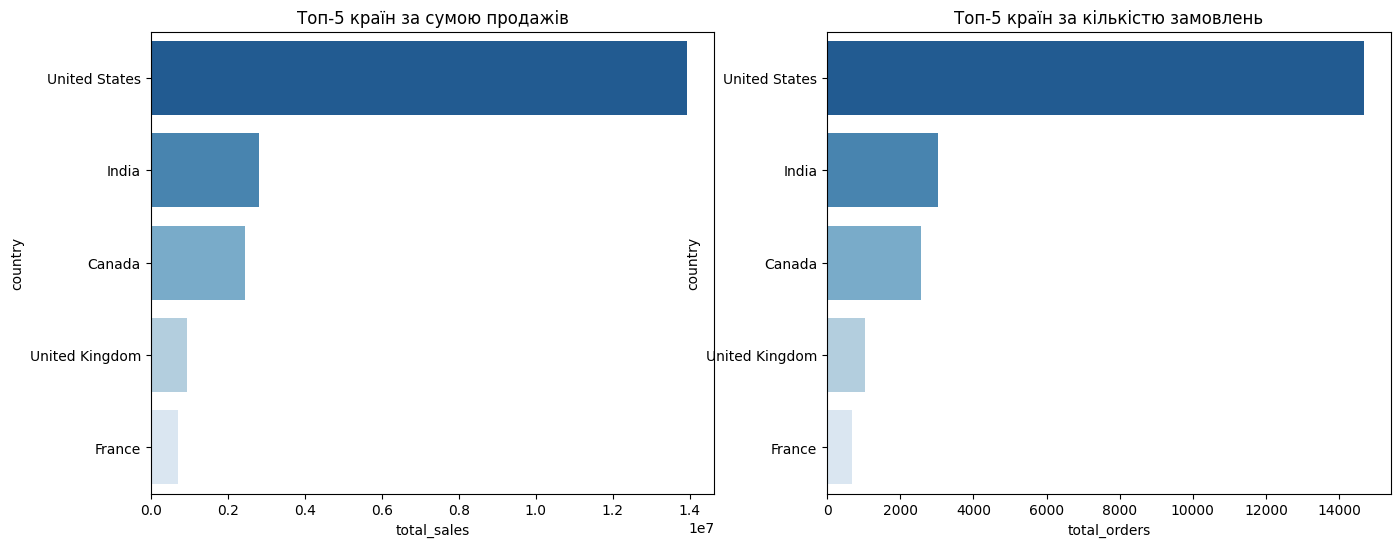

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=country_stats.reset_index(), x='total_sales', y='country', ax=axes[0], palette='Blues_r')
axes[0].set_title('Топ-5 країн за сумою продажів')
sns.barplot(data=country_stats.reset_index(), x='total_orders', y='country', ax=axes[1], palette='Blues_r')
axes[1].set_title('Топ-5 країн за кількістю замовлень')


* Ми бачимо, що топ- 3 континенти за продажами: Америка, Азія, Європа.
* Топ-5 країн за сумою продажів: США, Індія, Канада, Велика Британія, Франція.
* Топ-5 країн за кількістю замовлень:США, Індія, Канада, Велика Британія, Франція.

Тобто за кількістю замовлень та сумою продажів в нас лідирують одні і ті самі країни.

# Топ-10 категорій товарів (Загальний vs Країна №1)

In [ ]:

top_categories_global = orders_df.groupby('category')['price'].sum().sort_values(ascending=False).head(10)

top_country = country_stats.index[0]

top_categories_country = orders_df[orders_df['country'] == top_country].groupby('category')['price'].sum().sort_values(ascending=False).head(10)

print(f" ЗАГАЛЬНИЙ ТОП-10 КАТЕГОРІЙ ")
print(top_categories_global)
print(f"ТОП-10 КАТЕГОРІЙ У КРАЇНІ {top_country} ")
print(top_categories_country)

 ЗАГАЛЬНИЙ ТОП-10 КАТЕГОРІЙ 
category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: price, dtype: float64
ТОП-10 КАТЕГОРІЙ У КРАЇНІ United States 
category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer units     382388.0
Bar furniture                        330805.0
Children's

* Загальний ТОП-10 категорій (Global)
Apparel (Одяг) — $837,212.16

Office (Офісні товари) — $381,208.64

Drinkware (Посуд для напоїв) — $272,333.15

Lifestyle (Товари для життя/хобі) — $123,089.44

Nest (Розумний дім / екосистеми) — $108,794.75

Bags (Сумки) — $103,426.32

Notebooks (Блокноти/Нотатники) — $74,481.19

Headphones (Навушники) — $50,458.74

Small Accessories (Дрібні аксесуари) — $36,365.17

Nest-Canada — $15,700.86

* ТОП-10 категорій у США (United States)
Apparel — $398,710.22

Office — $219,307.74

Drinkware — $128,735.63

Lifestyle — $63,554.43

Nest — $50,113.33

Bags — $48,740.73

Notebooks — $35,847.66

Headphones — $24,534.69

Small Accessories — $18,337.38

Gift Cards (Подарункові карти) — $4,473.50

# Продажі у розрізі девайсів та моделей (у % від загальних)

In [ ]:
total_revenue = orders_df['price'].sum()

device_shares = (orders_df.groupby('device')['price'].sum() / total_revenue * 100).sort_values(ascending=False)

model_shares = (orders_df.groupby('device_model')['price'].sum() / total_revenue * 100).sort_values(ascending=False).head(10)

print("ЧАСТКА ПРОДАЖІВ ЗА ТИПАМИ ДЕВАЙСІВ (%)")
print(device_shares.round(2))
print(" ТОП-10 МОДЕЛЕЙ ЗА ЧАСТКОЮ В ПРОДАЖАХ (%) ")
print(model_shares.round(2))


ЧАСТКА ПРОДАЖІВ ЗА ТИПАМИ ДЕВАЙСІВ (%)
device
desktop    59.00
mobile     38.73
tablet      2.26
Name: price, dtype: float64
 ТОП-10 МОДЕЛЕЙ ЗА ЧАСТКОЮ В ПРОДАЖАХ (%) 
device_model
Chrome        27.84
<Other>       20.44
Safari        20.30
iPhone        20.08
ChromeBook     5.73
Edge           2.18
iPad           1.40
Firefox        1.32
Pixel 4 XL     0.37
Pixel 3        0.34
Name: price, dtype: float64


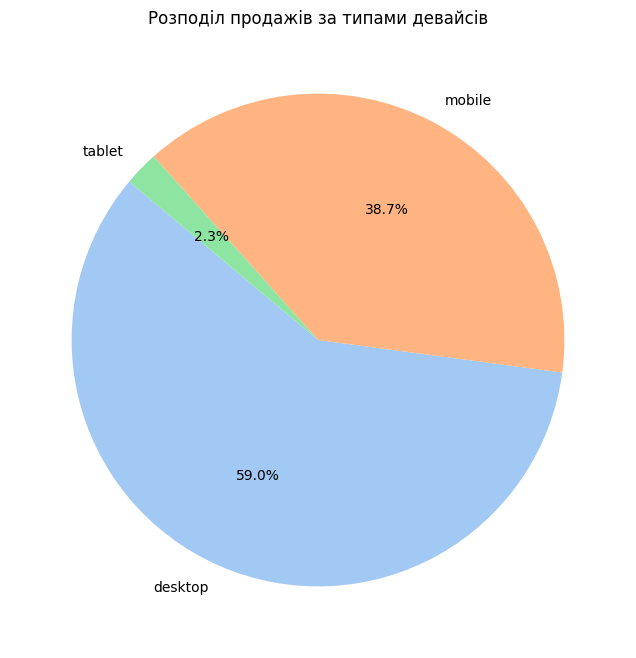

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(device_shares, labels=device_shares.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('Розподіл продажів за типами девайсів')
plt.show()

# Розподіл за типами девайсів (Device Types)
* desktop (Комп'ютери та ноутбуки): 59%.
* mobile (Мобільні телефони): 38.7%.
* tablet (Планшети): 2.3% .

# Топ-5 моделей девайсів за часткою у продажах
* Chrome - 27.84 %.
* Safari - 20.30%.
* iPhone - 20.08%.
* ChromeBook - 5.73 %.
* Edge - 2.18 %.

# Продажі за джерелами та каналами трафіку (у %)

In [ ]:
source_shares = (orders_df.groupby('traffic_source')['price'].sum() / total_revenue * 100).sort_values(ascending=False)
channel_shares = (orders_df.groupby('traffic_channel')['price'].sum() / total_revenue * 100).sort_values(ascending=False)

print("ЧАСТКА ЗА ДЖЕРЕЛАМИ (MEDIUM) (%)")
print(source_shares.round(2))
print("ЧАСТКА ЗА КАНАЛАМИ (CHANNEL) (%)")
print(channel_shares.round(2))

ЧАСТКА ЗА ДЖЕРЕЛАМИ (MEDIUM) (%)
traffic_source
organic           34.20
(none)            23.44
referral          17.65
<Other>           14.05
(data deleted)     6.39
cpc                4.27
Name: price, dtype: float64
ЧАСТКА ЗА КАНАЛАМИ (CHANNEL) (%)
traffic_channel
Organic Search    35.76
Paid Search       26.62
Direct            23.44
Social Search      7.92
Undefined          6.26
Name: price, dtype: float64


* Ми бачимо хороший органічний трафік 37%, також бачисо що реклама дала 26% трафіку, та добре працює і прямий вхід за пошуком 23%.


У висновку бачимо, що добре працюють алгоритми сайту і наша продукі вгорі, реклама також приносить великий потік трафіку та й відомість нашого бренду дає доволі івеликий відсоток трафіку 23%.

# Аналіз зареєстрованих користувачів (Акаунти)

In [ ]:
users_unique = df[df['user_id'].notna()].drop_duplicates(subset=['user_id'])
total_registered = len(users_unique)


confirmed_pct = (users_unique['is_email_confirmed'].sum() / total_registered) * 100
unsubscribed_pct = (users_unique['is_subscribed'].sum() / total_registered) * 100

print(f"Загалом зареєстрованих користувачів: {total_registered}")
print(f"Відсоток користувачів, що ПІДТВЕРДИЛИ email: {confirmed_pct:.2f}%")
print(f"Відсоток користувачів, що ВІДПИСАЛИСЯ від розсилки: {unsubscribed_pct:.2f}%")

Загалом зареєстрованих користувачів: 27945
Відсоток користувачів, що ПІДТВЕРДИЛИ email: 71.70%
Відсоток користувачів, що ВІДПИСАЛИСЯ від розсилки: 16.94%


In [ ]:
registered_sessions = df[df['user_id'].notna()]

# Рахуємо середній чек та кількість замовлень для обох груп
subscription_behavior = registered_sessions.groupby('is_subscribed').agg(
    total_sales=('price', 'sum'),
    orders_count=('price', 'count'),
    avg_check=('price', 'mean')
)

subscription_behavior.index = ['Підписані (0)', 'Відписані (1)']
print("ПОВЕДІНКА КОРИСТУВАЧІВ ЗА СТАТУСОМ ПІДПИСКИ")
print(subscription_behavior)

ПОВЕДІНКА КОРИСТУВАЧІВ ЗА СТАТУСОМ ПІДПИСКИ
               total_sales  orders_count   avg_check
Підписані (0)    2150796.9          2334  921.506812
Відписані (1)     431721.6           447  965.820134


In [ ]:
top_countries_users = users_unique['country'].value_counts().head(5)
print("ТОП-5 КРАЇН ЗА КІЛЬКІСТЮ ЗАРЕЄСТРОВАНИХ ЮЗЕРІВ")
print(top_countries_users)

ТОП-5 КРАЇН ЗА КІЛЬКІСТЮ ЗАРЕЄСТРОВАНИХ ЮЗЕРІВ
country
United States     12384
India              2687
Canada             2067
United Kingdom      859
France              553
Name: count, dtype: int64


# ТОП-5 КРАЇН ЗА КІЛЬКІСТЮ ЗАРЕЄСТРОВАНИХ ЮЗЕРІВ
* United States - 12384
* India - 2687
* Canada - 2067
*  United Kingdom - 859
* France - 553

Бачимо, що повторює наші тпи за продажаи та кількістю замовленннями.

# ПОВЕДІНКА КОРИСТУВАЧІВ ЗА СТАТУСОМ ПІДПИСКИ
Підписані - 2150796.9, кількість замолень - 2334, середній чек - 921.506812.
Відписані - 431721.6, кількість замолень - 447, середній чек -  965.820134.
Висновок бачимо, що відписані користувачі роблять менше замовлень, проте їх середній чек більший, що свідчить про цільові дорогі замовлення.



# Зв'язок верифікації email та конверсії

In [ ]:
conversion_by_verification = registered_sessions.groupby('is_email_confirmed').agg(
    total_sessions=('session_id', 'nunique'),
    purchases=('price', 'count')
)
conversion_by_verification['conversion_rate (%)'] = (conversion_by_verification['purchases'] / conversion_by_verification['total_sessions']) * 100
conversion_by_verification.index = ['Невериф. email (0)', 'Верифікований email (1)']

print("ВПЛИВ ВЕРИФІКАЦІЇ EMAIL НА КОНВЕРСІЮ ")
print(conversion_by_verification)

ВПЛИВ ВЕРИФІКАЦІЇ EMAIL НА КОНВЕРСІЮ 
                         total_sessions  purchases  conversion_rate (%)
Невериф. email (0)                 7909        792            10.013908
Верифікований email (1)           20036       1989             9.927131


/tmp/ipykernel_763/392728012.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_by_verification.index, y='conversion_rate (%)', data=conversion_by_verification, palette='Set2')


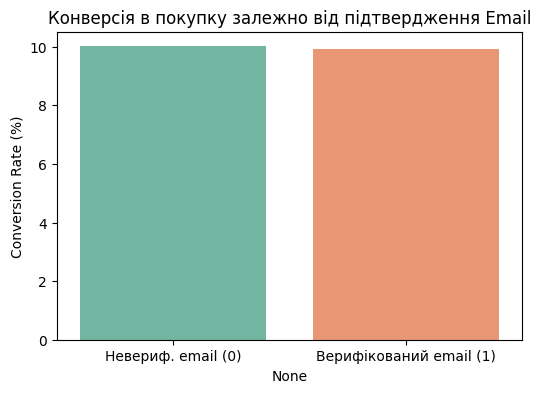

In [ ]:

plt.figure(figsize=(6, 4))
sns.barplot(x=conversion_by_verification.index, y='conversion_rate (%)', data=conversion_by_verification, palette='Set2')
plt.title('Конверсія в покупку залежно від підтвердження Email')
plt.ylabel('Conversion Rate (%)')
plt.show()

* Різниця між двома показниками становить усього 0.08%. Це означає, що сам факт підтвердження електронної адреси взагалі не впливає на бажання та готовність користувача здійснити покупку. Обидві групи конвертуються з однаковою ефективністю.
* Сесій від верифікованих користувачів майже в 2.5 рази більше (20 036 проти 7 909). Це означає, що люди, які підтвердили email, є більш лояльними та довгостроковими клієнтами — вони частіше повертаються на сайт


# Аналіз динаміки продажів.




In [ ]:
# Перетворюємо дату в правильний формат та фільтруємо лише успішні замовлення
df['order_date'] = pd.to_datetime(df['order_date'])
orders_df = df[df['price'].notna()].copy()

## Загальна динаміка продажів та аналіз сезонності

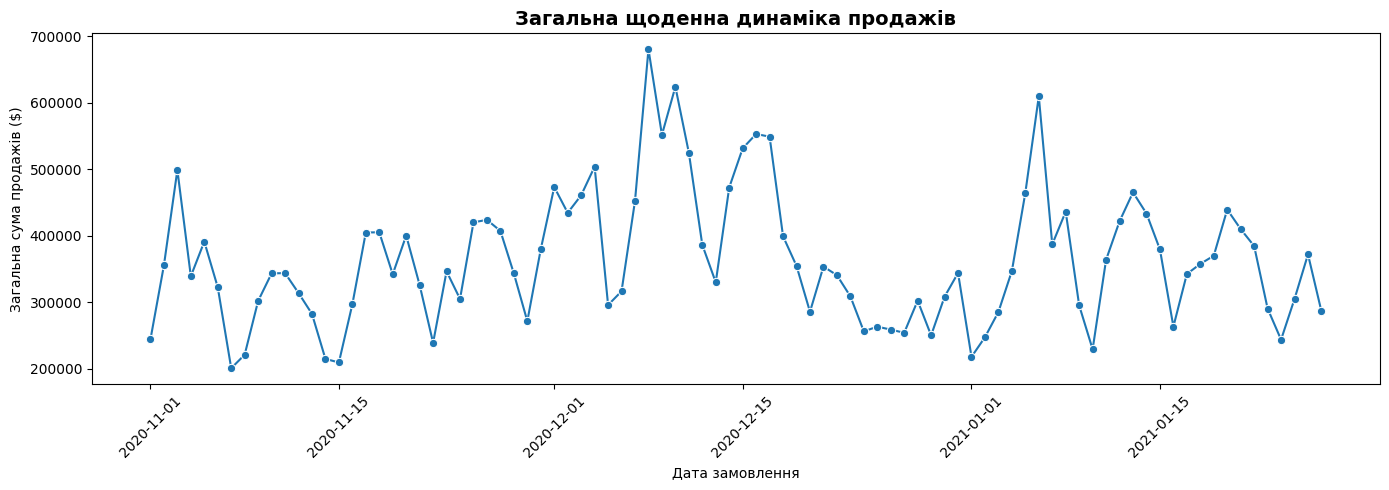

In [ ]:
daily_sales = orders_df.groupby('order_date')['price'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_sales, x='order_date', y='price', marker='o')
plt.title('Загальна щоденна динаміка продажів', fontsize=14, fontweight='bold')
plt.xlabel('Дата замовлення')
plt.ylabel('Загальна сума продажів ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* тижнева сезонність — у будні дні продажі злітають, а на вихідних різко падають.
* Найвища точка на всьому графіку припадає на першу половину грудня . Це класичний сезонний аномальний стрибок - люди масово скуповують подарунки до свят.
* На початку січня видно ще один раптовий потужний пік. Це можуть бути або післяноворічні розпродажі.


## Динаміка продажів у розрізі континентів (Америка, Азія, Європа)

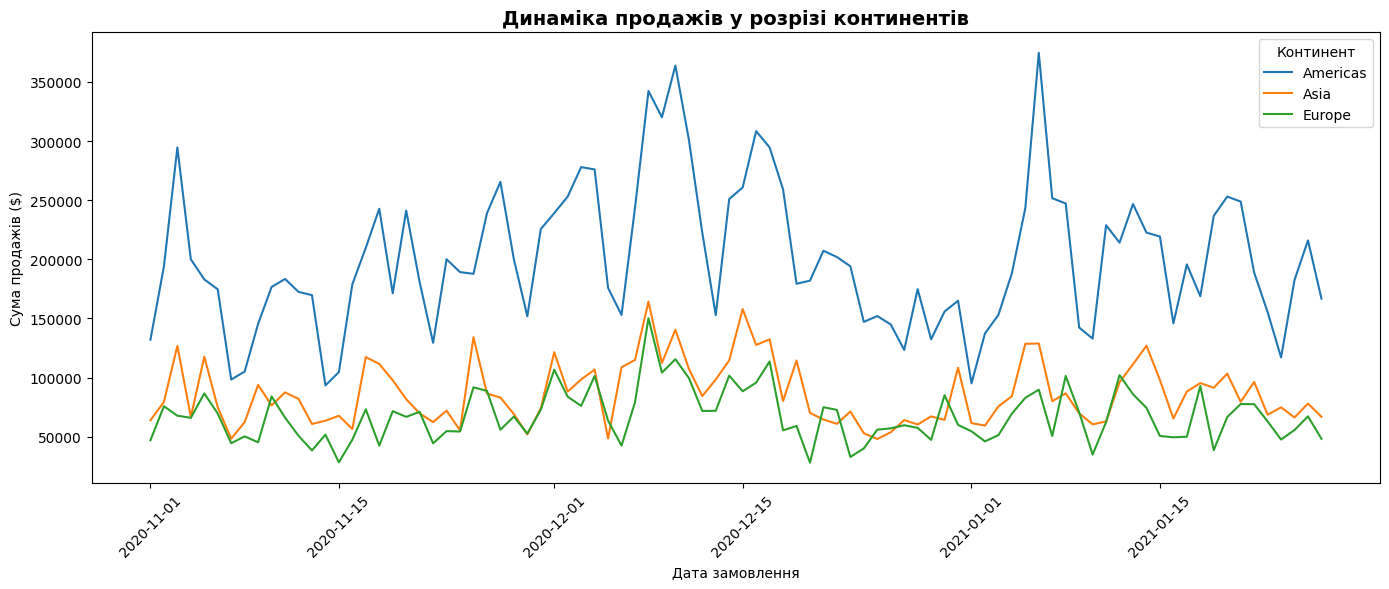

In [ ]:
target_continents = ['Americas', 'Asia', 'Europe']
continent_dynamics = orders_df[orders_df['continent'].isin(target_continents)].groupby(['order_date', 'continent'])['price'].sum().reset_index()


plt.figure(figsize=(14, 6))
sns.lineplot(data=continent_dynamics, x='order_date', y='price', hue='continent')

plt.title('Динаміка продажів у розрізі континентів', fontsize=14, fontweight='bold')
plt.xlabel('Дата замовлення')
plt.ylabel('Сума продажів ($)')
plt.legend(title='Континент')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Тренди в Азії та Європі рухаються абсолютно синхронно з Америкою. Передноворічний пік на початку грудня та спад наприкінці місяця відбуваються на всіх трьох континентах одночасно.

## Динаміка продажів у розрізі каналів трафіку

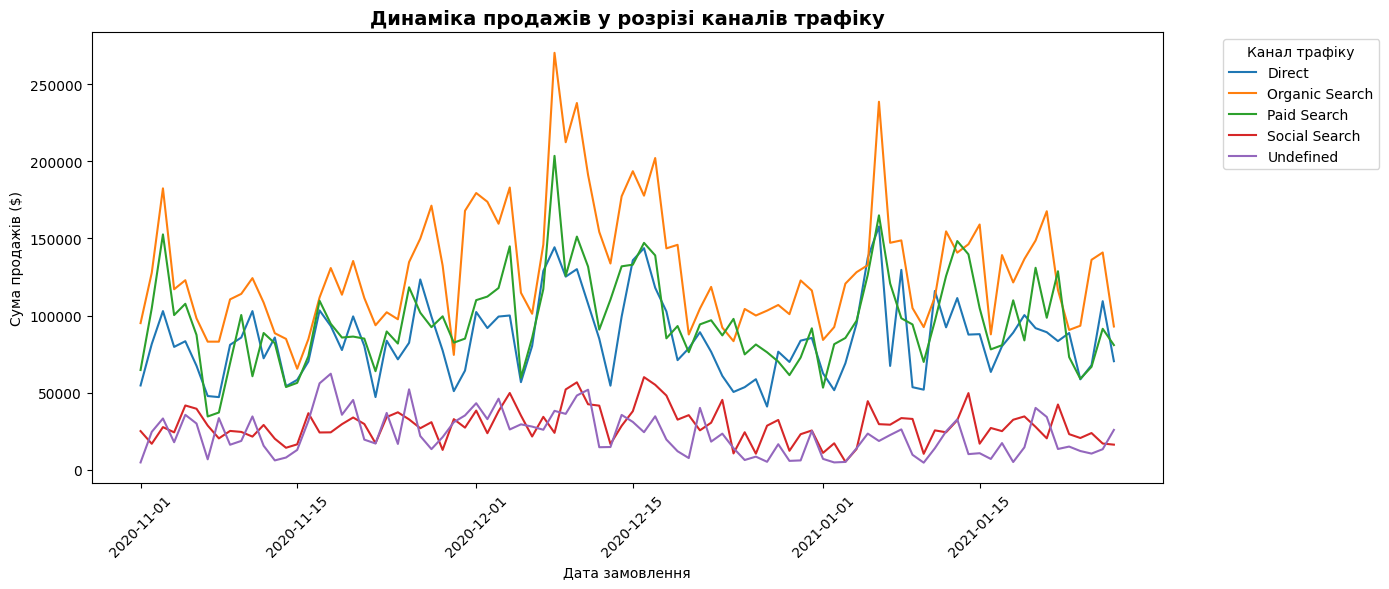

In [ ]:
channel_dynamics = orders_df.groupby(['order_date', 'traffic_channel'])['price'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=channel_dynamics, x='order_date', y='price', hue='traffic_channel')
plt.title('Динаміка продажів у розрізі каналів трафіку', fontsize=14, fontweight='bold')
plt.xlabel('Дата замовлення')
plt.ylabel('Сума продажів ($)')
plt.legend(title='Канал трафіку', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Organic Search  та Paid Search стабільно йдуть на самому верху. Саме вони принесли найбільший виторг під час грудневого та січневого піків

## Динаміка продажів у розрізі типів девайсів


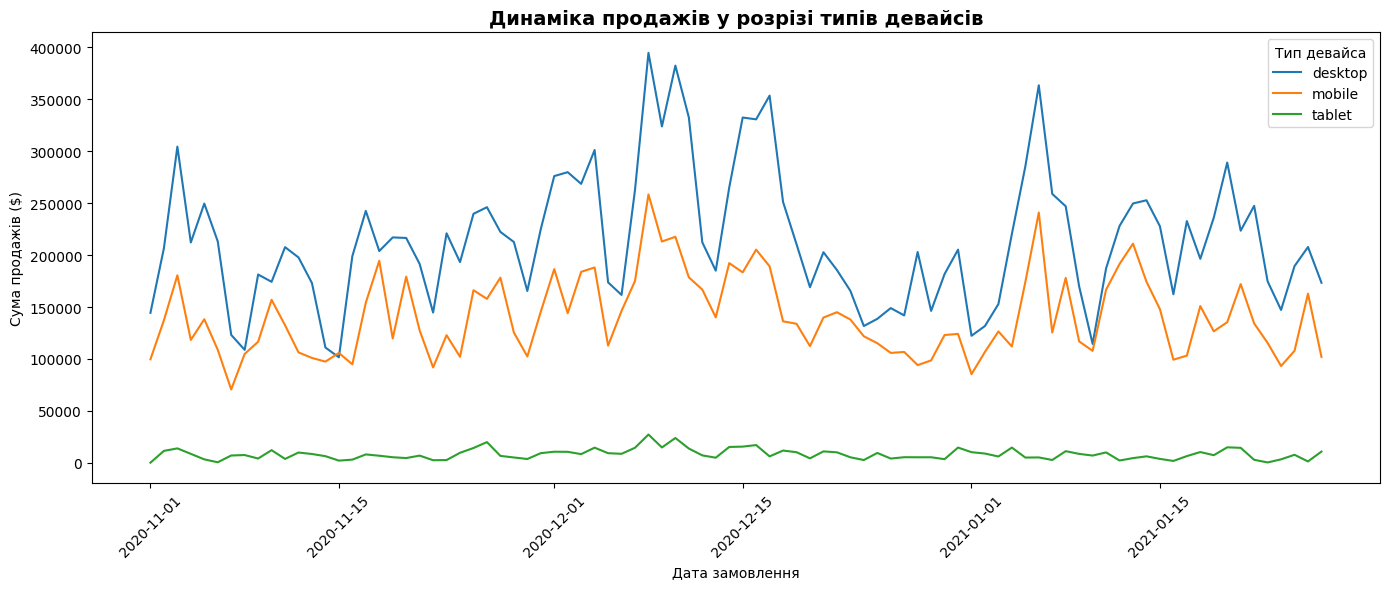

In [ ]:
device_dynamics = orders_df.groupby(['order_date', 'device'])['price'].sum().reset_index()

plt.figure(figsize=(14, 6))

sns.lineplot(data=device_dynamics, x='order_date', y='price', hue='device')
plt.title('Динаміка продажів у розрізі типів девайсів', fontsize=14, fontweight='bold')
plt.xlabel('Дата замовлення')
plt.ylabel('Сума продажів ($)')
plt.legend(title='Тип девайса')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Desktop: беззаперечно лідирує з величезним відривом протягом усіх трьох місяців. Під час піків у грудні та січні  замовлення з комп'ютерів робили основну касу.

Mobile: йде строго на другому місці, повторюючи форму десктопа. З телефонів купують стабільно, але суми менші.


# Зведені таблиці


In [ ]:
clean_sessions = df[df['traffic_channel'].notna() & df['device'].notna()].copy()
clean_sessions = clean_sessions[~clean_sessions['traffic_channel'].isin(['<Other>', 'Undefined', '(data deleted)'])]

orders_df = df[df['price'].notna()].copy()

## КІЛЬКІСТЬ СЕСІЙ

In [ ]:
pivot_sessions = clean_sessions.pivot_table(
    index='traffic_channel',
    columns='device',
    values='session_id',
    aggfunc='nunique',
    fill_value=0
)

print("КІЛЬКІСТЬ СЕСІЙ")
display(pivot_sessions)

КІЛЬКІСТЬ СЕСІЙ


device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638


## ТОП-10 КАТЕГОРІЙ У ТОП-5 КРАЇНАХ

In [ ]:
top_countries = orders_df.groupby('country')['price'].sum().nlargest(5).index
top_categories = orders_df.groupby('category')['price'].sum().nlargest(10).index


filtered_orders = orders_df[orders_df['country'].isin(top_countries) & orders_df['category'].isin(top_categories)]

pivot_sales = filtered_orders.pivot_table(
    index='category',
    columns='country',
    values='price',
    aggfunc='sum',
    fill_value=0)

pivot_sales = pivot_sales.loc[top_categories, top_countries]

print(" ТОП-10 КАТЕГОРІЙ У ТОП-5 КРАЇНАХ")
display(pivot_sales.round(2))

 ТОП-10 КАТЕГОРІЙ У ТОП-5 КРАЇНАХ


country,United States,India,Canada,United Kingdom,France
category,,,,,
Sofas & armchairs,3707144.5,788430.0,692427.5,234812.0,187735.0
Chairs,2619773.8,544309.2,417740.8,188519.4,134029.4
Beds,2213058.0,358319.5,354772.0,133816.0,116414.0
Bookcases & shelving units,1567606.9,364507.4,278981.9,113987.6,73830.0
Cabinets & cupboards,994545.5,191888.0,181802.0,71684.5,59101.5
Outdoor furniture,929245.2,162289.4,185322.8,57002.4,40486.4
Tables & desks,777865.0,186157.5,132678.0,49374.0,42299.0
Chests of drawers & drawer units,382388.0,73111.0,71952.0,36784.0,21544.5
Bar furniture,330805.0,57657.0,51724.0,22103.0,11199.0


## Середній чек замовлення (Континенти vs Браузери)

In [ ]:
top_browsers = orders_df['browser'].value_counts().head(3).index
filtered_browsers = orders_df[orders_df['browser'].isin(top_browsers)]

pivot_avg_check = filtered_browsers.pivot_table(
    index='continent',
    columns='browser',
    values='price',
    aggfunc='mean',
    fill_value=0)

print(" СЕРЕДНІЙ ЧЕК ЗА БРАУЗЕРАМИ ТА КОНТИНЕНТАМИ")
display(pivot_avg_check.round(2))

 СЕРЕДНІЙ ЧЕК ЗА БРАУЗЕРАМИ ТА КОНТИНЕНТАМИ


browser,<Other>,Chrome,Safari
continent,,,
(not set),1783.75,1015.38,1186.00
Africa,1270.40,945.74,1023.59
Americas,1046.79,960.48,911.14
Asia,1172.22,929.21,1003.55
Europe,963.92,929.60,1009.59
Oceania,941.12,1056.12,833.60


## ПРОДАЖІ ЗАРЕЄСТРОВАНИХ ЮЗЕРІВ ЗА ТРАФІКОМ ТА ПІДПИСКОЮ

In [ ]:
registered_orders = orders_df[orders_df['user_id'].notna() & orders_df['traffic_channel'].notna()]
registered_orders = registered_orders[~registered_orders['traffic_channel'].isin(['<Other>', 'Undefined', '(data deleted)'])]

pivot_marketing_subscription = registered_orders.pivot_table(
    index='traffic_channel',
    columns='is_subscribed',
    values='price',
    aggfunc='sum',
    fill_value=0)

pivot_marketing_subscription.columns = ['Активна підписка (0)', 'Відписалися (1)']

print("ПРОДАЖІ ЗАРЕЄСТРОВАНИХ ЮЗЕРІВ ЗА ТРАФІКОМ ТА ПІДПИСКОЮ ($) ")
display(pivot_marketing_subscription.round(2))

ПРОДАЖІ ЗАРЕЄСТРОВАНИХ ЮЗЕРІВ ЗА ТРАФІКОМ ТА ПІДПИСКОЮ ($) 


,Активна підписка (0),Відписалися (1)
traffic_channel,,
Direct,507388.2,101549.0
Organic Search,757788.9,176540.6
Paid Search,554274.6,86525.0
Social Search,164669.9,40470.0


# Статистичний аналіз взаємозв’язків


In [ ]:
from scipy.stats import pearsonr

df['order_date'] = pd.to_datetime(df['order_date'])
orders_df = df[df['price'].notna()].copy()

# Функція для автоматичного розрахунку кореляції та p-value для матриць
def calculate_p_values(df_matrix):
    cols = df_matrix.columns
    p_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), columns=cols, index=cols)
    for i in range(len(cols)):
        for j in range(len(cols)):
            if i == j:
                p_matrix.iloc[i, j] = np.nan
            else:
                # Очищаємо від NaN перед розрахунком
                tmp = df_matrix[[cols[i], cols[j]]].dropna()
                if len(tmp) > 1:
                    _, p_val = pearsonr(tmp[cols[i]], tmp[cols[j]])
                    p_matrix.iloc[i, j] = p_val
                else:
                    p_matrix.iloc[i, j] = np.nan
    return p_matrix

## Взаємозв’язок між кількістю сесій та загальними продажами

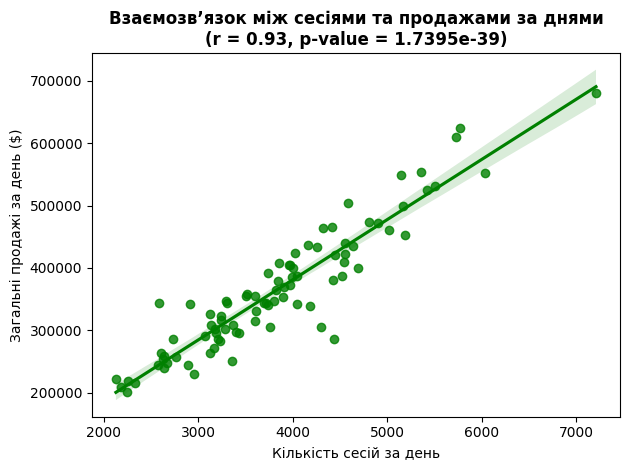

Коефіцієнт кореляції: 0.9313
p-value: 1.7394621412998283e-39


In [ ]:
daily_sessions = df.groupby('order_date')['session_id'].nunique().reset_index(name='total_sessions')
daily_revenue = orders_df.groupby('order_date')['price'].sum().reset_index(name='total_sales')

traffic_vs_sales = pd.merge(daily_sessions, daily_revenue, on='order_date', how='inner')

# Рахуємо кореляцію Пірсона та p-value
r_val, p_val = pearsonr(traffic_vs_sales['total_sessions'], traffic_vs_sales['total_sales'])


sns.regplot(data=traffic_vs_sales, x='total_sessions', y='total_sales', color='g', marker='o')
plt.title(f'Взаємозв’язок між сесіями та продажами за днями\n(r = {r_val:.2f}, p-value = {p_val:.4e})', fontsize=12, fontweight='bold')
plt.xlabel('Кількість сесій за день')
plt.ylabel('Загальні продажі за день ($)')
plt.tight_layout()
plt.show()

print(f"Коефіцієнт кореляції: {r_val:.4f}")
print(f"p-value: {p_val}")

Між трафіком та виторгом існує сильний позитивний зв'язок. Коефіцієнт 0.93 доводить, що збільшення кількості відвідувачів сайту практично лінійно конвертується в зростання продажів. p-value практично дорівнює нулю, що означає сильну статистичну значущість

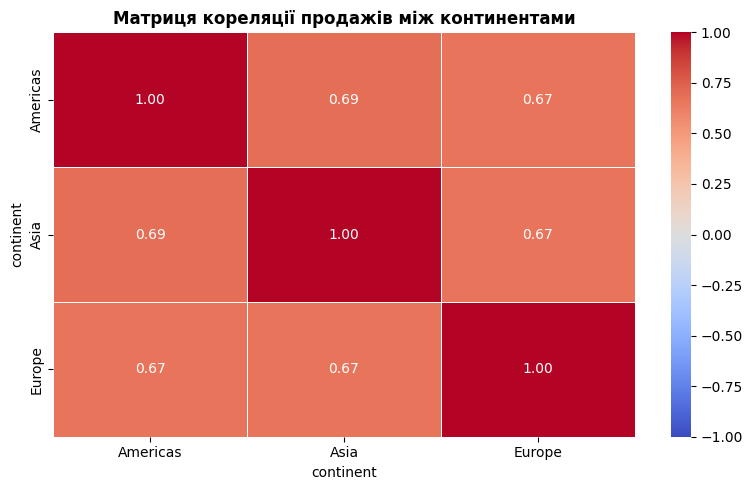

P-values для континентів (якщо < 0.05 — зв'язок значущий):


continent,Americas,Asia,Europe
continent,,,
Americas,NaN,8.004063e-14,9.911408e-13
Asia,8.004063e-14,NaN,1.190893e-12
Europe,9.911408e-13,1.190893e-12,NaN


In [ ]:
import numpy as np
continents = ['Americas', 'Asia', 'Europe']
continent_ts = orders_df[orders_df['continent'].isin(continents)].pivot_table(
    index='order_date', columns='continent', values='price', aggfunc='sum'
).fillna(0)

# Рахуємо кореляцію та p-values
matrix_corr_cont = continent_ts.corr()
matrix_p_cont = calculate_p_values(continent_ts)

plt.figure(figsize=(8, 5))
sns.heatmap(matrix_corr_cont, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Матриця кореляції продажів між континентами', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("P-values для континентів (якщо < 0.05 — зв'язок значущий):")
display(matrix_p_cont)

Продажі між Americas, Asia та Europe мають помірно сильний позитивний зв'язок.  Результат статистично значущий

## Кореляція продажів між різними каналами трафіку

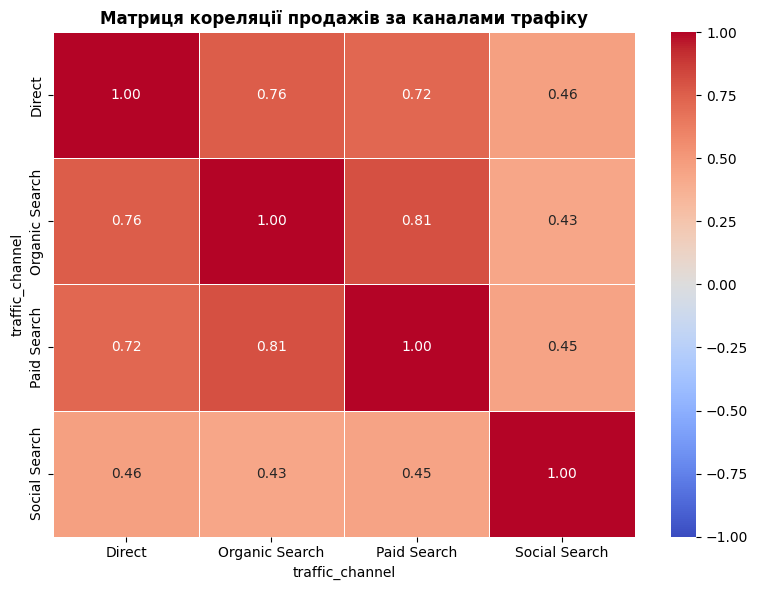

P-values для каналів трафіку:


traffic_channel,Direct,Organic Search,Paid Search,Social Search
traffic_channel,,,,
Direct,NaN,9.107881e-18,1.512880e-15,0.000006
Organic Search,9.107881e-18,NaN,1.755643e-21,0.000023
Paid Search,1.512880e-15,1.755643e-21,NaN,0.000010
Social Search,5.901047e-06,2.347593e-05,9.696038e-06,NaN


In [ ]:
channels_clean = orders_df[~orders_df['traffic_channel'].isin(['<Other>', 'Undefined', '(data deleted)'])]
channel_ts = channels_clean.pivot_table(
    index='order_date', columns='traffic_channel', values='price', aggfunc='sum'
).fillna(0)

matrix_corr_chan = channel_ts.corr()
matrix_p_chan = calculate_p_values(channel_ts)

plt.figure(figsize=(8, 6))
sns.heatmap(matrix_corr_chan, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Матриця кореляції продажів за каналами трафіку', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("P-values для каналів трафіку:")
display(matrix_p_chan)

Дуже висока кореляція між органічним та платним трафіком, бренд активно закуповує рекламу, впізнаваність компанії росте  люди починають частіше клікати на цей же бренд в органічній видачі.

## Кореляція продажів між топ-5 категоріями товарів

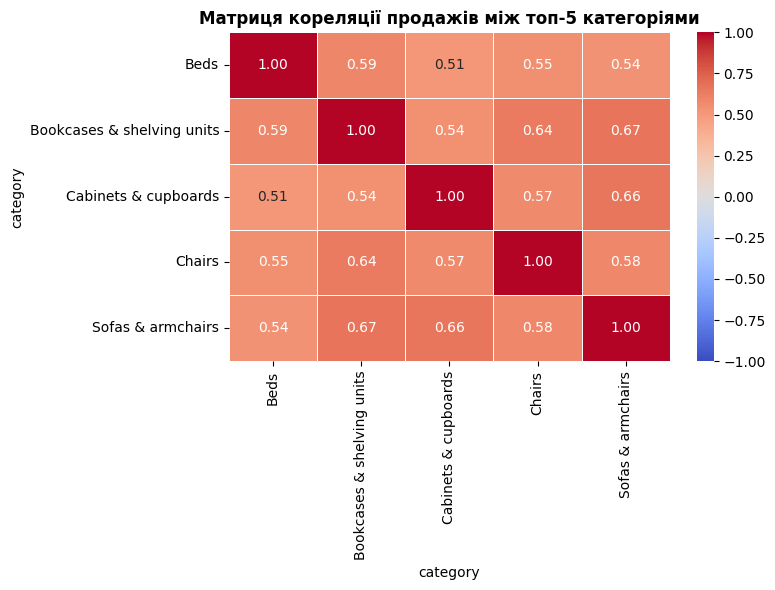

P-values для категорій товарів:


category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
category,,,,,
Beds,NaN,1.154998e-09,2.910930e-07,2.079183e-08,7.687333e-08
Bookcases & shelving units,1.154998e-09,NaN,5.867225e-08,2.504550e-11,1.406972e-12
Cabinets & cupboards,2.910930e-07,5.867225e-08,NaN,5.465903e-09,3.415056e-12
Chairs,2.079183e-08,2.504550e-11,5.465903e-09,NaN,3.638833e-09
Sofas & armchairs,7.687333e-08,1.406972e-12,3.415056e-12,3.638833e-09,NaN


In [ ]:
top5_categories = orders_df.groupby('category')['price'].sum().nlargest(5).index
cat_ts = orders_df[orders_df['category'].isin(top5_categories)].pivot_table(index='order_date', columns='category', values='price', aggfunc='sum').fillna(0)

matrix_corr_cat = cat_ts.corr()
matrix_p_cat = calculate_p_values(cat_ts)

plt.figure(figsize=(8, 6))
sns.heatmap(matrix_corr_cat, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Матриця кореляції продажів між топ-5 категоріями', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("P-values для категорій товарів:")
display(matrix_p_cat)

Найвища кореляція спостерігається між категоріями Bookcases & shelving units та Sofas & armchairs

## Кореляція між середнім чеком та кількістю куплених товарів за день

In [ ]:
import pandas as pd
from scipy.stats import pearsonr

daily_basket = orders_df.groupby('order_date').agg(
    avg_price=('price', 'mean'),
    unique_categories=('category', 'nunique')
).reset_index()

r_basket, p_basket = pearsonr(daily_basket['avg_price'], daily_basket['unique_categories'])

print("Кореляція середнього чеку та різноманітності категорій за день")
print(f"Коефіцієнт r: {r_basket:.4f}")
print(f"p-value: {p_basket:.4e}")

print(f"Кореляція чеку та кількості товарів ")
print(f"Коефіцієнт r: {r_basket:.4f}, p-value: {p_basket:.4e}")

Кореляція середнього чеку та різноманітності категорій за день
Коефіцієнт r: 0.0599
p-value: 5.7946e-01
Кореляція чеку та кількості товарів 
Коефіцієнт r: 0.0599, p-value: 5.7946e-01


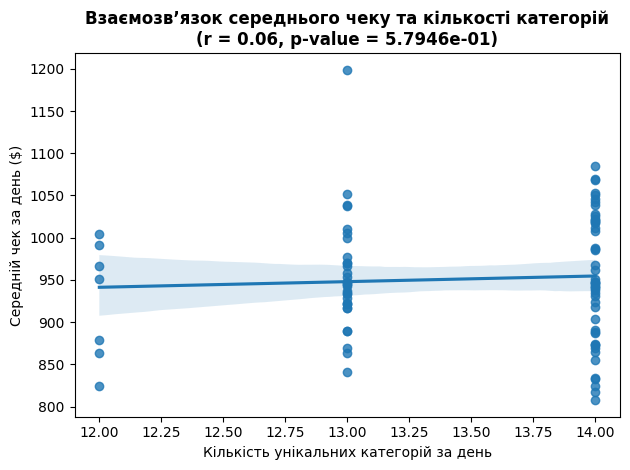

In [ ]:
sns.regplot(data=daily_basket, x='unique_categories', y='avg_price')

plt.title(f'Взаємозв’язок середнього чеку та кількості категорій\n(r = {r_basket:.2f}, p-value = {p_basket:.4e})', fontsize=12, fontweight='bold')
plt.xlabel('Кількість унікальних категорій за день')
plt.ylabel('Середній чек за день ($)')
plt.tight_layout()
plt.show()

Взаємозв'язку немає, а результат статистично НЕзначущий. Лінія регресії на графіку майже ідеально горизонтальна,  p-value= 0.579, що значно більше за поріг 0.05.

# Статистичний аналіз відмінностей між групами

##Продажі зареєстрованих vs незареєстрованих користувачів

In [ ]:
from scipy.stats import shapiro, mannwhitneyu, ttest_ind

Шапіро-Вілк (Зареєстровані): p-value = 0.0073
Шапіро-Вілк (Незареєстровані): p-value = 0.0026


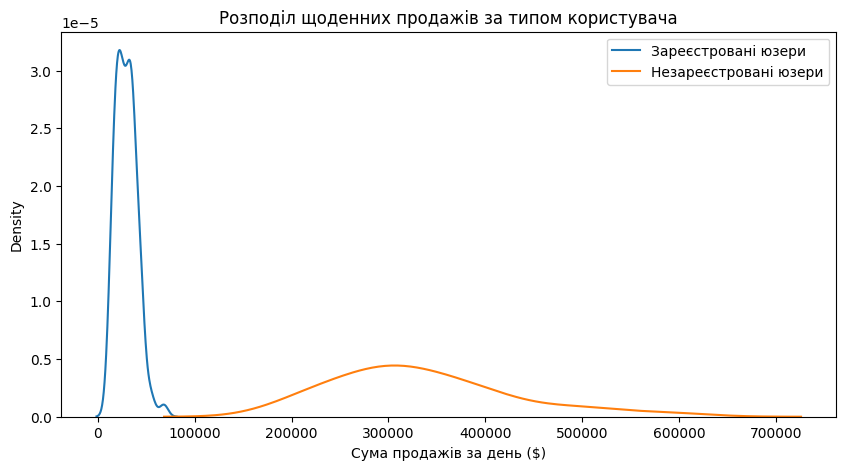


Застосовано тест: U-тест Манна-Вітні (непараметричний)
Статистика тесту = 0.0000, p-value = 2.2159e-30


In [ ]:
orders_df = df[df['price'].notna()].copy()

reg_sales = orders_df[orders_df['user_id'].notna()].groupby('order_date')['price'].sum()
unreg_sales = orders_df[orders_df['user_id'].isna()].groupby('order_date')['price'].sum()

# 2. Перевірка на нормальність (Тест Шапіро-Вілка)
stat_reg, p_reg = shapiro(reg_sales)
stat_unreg, p_unreg = shapiro(unreg_sales)

print(f"Шапіро-Вілк (Зареєстровані): p-value = {p_reg:.4f}")
print(f"Шапіро-Вілк (Незареєстровані): p-value = {p_unreg:.4f}")

# 3. Візуалізація розподілу
plt.figure(figsize=(10, 5))
sns.kdeplot(reg_sales, label='Зареєстровані юзери')
sns.kdeplot(unreg_sales, label='Незареєстровані юзери')
plt.title('Розподіл щоденних продажів за типом користувача')
plt.xlabel('Сума продажів за день ($)')
plt.legend()
plt.show()

# 4. Вибір та проведення тесту
if p_reg < 0.05 or p_unreg < 0.05:
    stat, p_test = mannwhitneyu(reg_sales, unreg_sales, alternative='two-sided')
    test_name = "U-тест Манна-Вітні (непараметричний)"
else:
    stat, p_test = ttest_ind(reg_sales, unreg_sales, equal_var=False)
    test_name = "T-критерій Стьюдента (параметричний)"

print(f"\nЗастосовано тест: {test_name}")
print(f"Статистика тесту = {stat:.4f}, p-value = {p_test:.4e}")

Тест Манна-Вітні підтвердив наявність статистично значущих відмінностей у щоденних продажах між зареєстрованими та незареєстрованими користувачами. На графіку розподілу чітко видно, що незареєстровані користувачі формують значно більший обсяг щоденного виторг, тоді як зареєстровані користувачі стабільно генерують менші обсяги щоденних продажів.

## Кількість сесій за різними каналами трафіку

АНАЛІЗ КІЛЬКОСТІ СЕСІЙ ЗА КАНАЛАМИ ТРАФІКУ 
Критерій Краскела-Волліса: Статистика = 260.4815, p-value = 3.5370e-56


/tmp/ipykernel_763/553584806.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=channels_clean, x='traffic_channel', y=df.groupby(['order_date', 'traffic_channel'])['session_id'].transform('nunique'), palette='Set2')


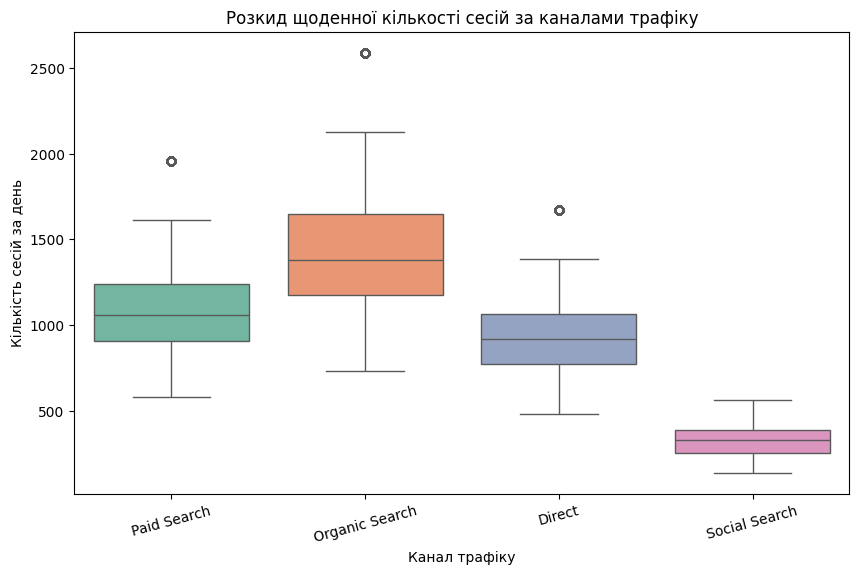

In [ ]:
from scipy.stats import kruskal, f_oneway
# Будуємо таблицю
channels_clean = df[~df['traffic_channel'].isin(['<Other>', 'Undefined', '(data deleted)']) & df['traffic_channel'].notna()]
sessions_by_channel = channels_clean.pivot_table(
    index='order_date', columns='traffic_channel', values='session_id', aggfunc='nunique').fillna(0)

# Збираємо дані по кожному каналу в окремі списки для тесту
groups = [sessions_by_channel[col].values for col in sessions_by_channel.columns]

# Перевіряємо розподіл
stat_kw, p_kw = kruskal(*groups)

print("АНАЛІЗ КІЛЬКОСТІ СЕСІЙ ЗА КАНАЛАМИ ТРАФІКУ ")
print(f"Критерій Краскела-Волліса: Статистика = {stat_kw:.4f}, p-value = {p_kw:.4e}")

# Візуалізуємо відмінності через Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=channels_clean, x='traffic_channel', y=df.groupby(['order_date', 'traffic_channel'])['session_id'].transform('nunique'), palette='Set2')
plt.title('Розкид щоденної кількості сесій за каналами трафіку')
plt.ylabel('Кількість сесій за день')
plt.xlabel('Канал трафіку')
plt.xticks(rotation=15)
plt.show()

* Лідером за кількістю залучених сесій за день є Organic Search (медіана близько 1400 сесій), на другому місці - Paid Search та Direct.
* Найменшу кількість сесій стабільно генерує Social Search (медіана нижче 500 сесій). Крім того, у каналах Paid Search, Organic Search та Direct спостерігаються помітні аномальні викиди в окремі дні, що свідчить про періодичні сплески активності.

##Доля сесій з органічним трафіку

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

geo_df = df[df['continent'].isin(['Americas', 'Europe']) & df['traffic_channel'].notna()].copy()

# загальнa кількість унікальних сесій для кожного континенту
total_americas = geo_df[geo_df['continent'] == 'Americas']['session_id'].nunique()
total_europe = geo_df[geo_df['continent'] == 'Europe']['session_id'].nunique()

#  сесії з Organic Search
organic_americas = geo_df[(geo_df['continent'] == 'Americas') & (geo_df['traffic_channel'] == 'Organic Search')]['session_id'].nunique()
organic_europe = geo_df[(geo_df['continent'] == 'Europe') & (geo_df['traffic_channel'] == 'Organic Search')]['session_id'].nunique()

print(f"Америка: {organic_americas} органічних сесій з {total_americas} ({organic_americas/total_americas*100:.2f}%)")
print(f"Європа: {organic_europe} органічних сесій з {total_europe} ({organic_europe/total_europe*100:.2f}%)")

# Масиви для Z-тесту
count = np.array([organic_americas, organic_europe])
nobs = np.array([total_americas, total_europe])

# Проводимо двовибірковий Z-тест часток
z_stat, p_z = proportions_ztest(count, nobs)

print(f"\nДвовибірковий Z-тест пропорцій: Z-статистика = {z_stat:.4f}, p-value = {p_z:.4e}")

Америка: 68671 органічних сесій з 193179 (35.55%)
Європа: 23195 органічних сесій з 65135 (35.61%)

Двовибірковий Z-тест пропорцій: Z-статистика = -0.2895, p-value = 7.7219e-01


Статистично значущих відмінностей між долями органічного трафіку в Європі та Америці не виявлено. Різниця у частках (35.55% проти 35.61%) є мінімальною та суто випадковою.

##Парний T-критерій Стьюдента

In [ ]:
from scipy.stats import ttest_rel

# Порівняємо, наприклад, чи відрізняються щоденні продажі в понеділок та вівторок
daily_sales = orders_df.groupby(['order_date'])['price'].sum().reset_index()
daily_sales['day_of_week'] = daily_sales['order_date'].dt.day_name()

mondays = daily_sales[daily_sales['day_of_week'] == 'Monday']['price'].values
tuesdays = daily_sales[daily_sales['day_of_week'] == 'Tuesday']['price'].values

min_len = min(len(mondays), len(tuesdays))
stat_rel, p_rel = ttest_rel(mondays[:min_len], tuesdays[:min_len])

print("ПАРНИЙ Т-ТЕСТ (ПОНЕДІЛКИ VS ВІВТОРКИ)")
print(f"Парний Т-критерій: Статистика = {stat_rel:.4f}, p-value = {p_rel:.4f}")

ПАРНИЙ Т-ТЕСТ (ПОНЕДІЛКИ VS ВІВТОРКИ)
Парний Т-критерій: Статистика = -2.9266, p-value = 0.0127


ми маємо статистично значущу відмінність у продажах між цими днями тижня. Негативна статистика показує, що продажі у вівторки в середньому є вищими, ніж у понеділки, що вказує на певний тижневий патерн купівельної спроможності.

## Взаємозв'язок категоріальних змінних

In [ ]:
 from scipy.stats import chi2_contingency

df['is_purchased'] = df['price'].notna().astype(int)


contingency_table = pd.crosstab(df['device'], df['is_purchased'])

print("TАБЛИЦЯ СПРЯЖЕНОСТІ ДЛЯ ХІ-КВАДРАТ ")
display(contingency_table)

# Тест Хі-квадрат
chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)
print(f" Хі-квадрат: Статистика = {chi2:.4f}, p-value = {p_chi2:.4e}")

TАБЛИЦЯ СПРЯЖЕНОСТІ ДЛЯ ХІ-КВАДРАТ 


is_purchased,0,1
device,,
desktop,184727,19702
mobile,124154,13113
tablet,7126,723


 Хі-квадрат: Статистика = 2.0392, p-value = 3.6074e-01


тип пристрою (desktop, mobile, tablet) не має статистично значущого зв'язку з фактом здійснення покупки. Конверсія в замовлення не залежить від девайсу, яким користується клієнт

In [ ]:
df.to_csv('cleaned_ecommerce_data.csv', index=False)


https://public.tableau.com/app/profile/.17026898/viz/_17837689433070/Dashboard1?publish=yes


## Скільки грошей приніс магазин за досліджуваний період та який тренд ми бачимо у щоденних продажах?
* Загальний виторг компанії склав 23.6 млн. Динаміка продажів по днях показує стабільний попит без різких провалів, але з помітним поступовим зниженням ближче до кінця аналізованого періоду (з ~1.2 млн на день до ~350 тис.). Це може сигналізувати про сезонність або завершення маркетингової кампанії.

## Яка частка зареєстрованих користувачів і чому це важливо для маркетингу?
* Лише 8.09% від загального виторгу приносять зареєстровані користувачі, тоді як 91.91% — це незареєстровані гості. Бізнес критично залежить від «одноразових» покупок.

## Які категорії товарів генерують основний виторг?
*  Абсолютним лідером продажів є категорія Sofas & armchairs - вона принесла понад 8 млн виторгу. За нею йдуть Chairs та Beds. Це свідчить про те, що магазин спеціалізується на великих, дорогих покупках для дому, де середній чек високий.

## Які джерела трафіку працюють найкраще, а які просідають?
* Найбільшу кількість сесій забезпечує Organic Search  та Paid Search. Водночас Social Search просідає.